# 온라인 도매 거래 취소 패턴 분석

**연구 질문**
1. 국가별·요일/시간대별로 취소율에 구조적 차이가 있는가?
2. 주문 수량(대량구매 여부)이 취소 발생과 관련이 있는가?
3. 특정 상품군에서 취소율이 유독 높게 나타나는가?

---

## Step 1. 데이터 로드 및 전처리

- 데이터 로드
- 타입/결측치 확인
- is_cancelled 변수 생성 및 검증

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정 
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [2]:
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')



In [6]:
df = pd.read_csv(r'C:\Users\USER\online_retail_II_dataset\online_retail_II.csv', encoding='ISO-8859-1')
print('전체 shape:', df.shape)
df.head()

전체 shape: (1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [8]:
#데이터 타입 및 기본 정보 확인

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 136.6 MB


### 결측치 처리 방침

- **Description (0.41% 결측)**: 상품 코드는 있지만 이름이 비어있는 경우. 비중이 매우 작아 상품군 관련 분석에서만 해당 행을 제외하고 진행함.
- **Customer ID (22.77% 결측)**: 비중이 큰 편이지만, 이번 분석은 고객 단위가 아니라 **거래(Invoice) 단위로 취소 여부**를 보는 것이 핵심이므로 지장 없다고 판단됨.

In [9]:
#결측치 확인

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'결측치 수': missing, '비율(%)': missing_pct})

,결측치 수,비율(%)
Invoice,0,0.00
StockCode,0,0.00
Description,4382,0.41
Quantity,0,0.00
InvoiceDate,0,0.00
Price,0,0.00
Customer ID,243007,22.77
Country,0,0.00


## 취소 거래 파생변수 생성

원본 데이터에는 "이 거래가 취소인지 아닌지"를 알려주는 컬럼이 없다.
다만 Invoice 번호가 'C'로 시작하면 취소 거래라는 규칙이 있어, 이를 이용해 `is_cancelled`라는 파생변수를 생성한다.

-> 이후의 분석(국가별/시간대별/상품별 취소율 비교)의 기준이 되는 핵심 변수!

In [10]:
# Invoice를 문자열로 변환 (str 함수를 쓰려면 문자열 타입이어야 함)
df['Invoice'] = df['Invoice'].astype(str)

In [11]:
# Invoice가 'C'로 시작하면 취소 거래로 판단해 새 컬럼 생성
df['is_cancelled'] = df['Invoice'].str.startswith('C')

In [12]:
# 취소 거래 수, 전체 거래 수, 취소율 계산
cancel_count = df['is_cancelled'].sum()
total_count = len(df)
cancel_rate = cancel_count / total_count * 100

print(f'전체 거래: {total_count:,}건')
print(f'취소 거래: {cancel_count:,}건')
print(f'전체 취소율: {cancel_rate:.2f}%')

전체 거래: 1,067,371건
취소 거래: 19,494건
전체 취소율: 1.83%


## 취소 거래 vs 정상 거래 기초 비교

`is_cancelled` 변수가 실제로 취소 거래를 올바르게 식별했는지 검증한다. (교차검증)
취소(반품) 거래는 시스템상 Quantity가 음수로 기록되므로, is_cancelled=True 그룹의 Quantity가 음수 위주로 나오는지 확인한다.

In [13]:
# is_cancelled 기준으로 그룹을 나누고, 각 그룹의 Quantity 기초 통계 확인
df.groupby('is_cancelled')['Quantity'].describe()

,count,mean,std,min,25%,50%,75%,max
is_cancelled,,,,,,,,
False,1047877.0,10.592354,135.280603,-9600.0,1.0,3.0,10.0,80995.0
True,19494.0,-25.186827,805.104908,-80995.0,-6.0,-2.0,-1.0,1.0


### 검증 결과

- `is_cancelled=True` 그룹의 평균 Quantity는 -25.19, 최댓값도 +1에 불과해
  대부분 음수로 기록되어 있음 → `is_cancelled` 변수가 취소 거래를
  올바르게 식별하고 있음을 확인.
- 다만 `is_cancelled=False` 그룹에도 최솟값이 -9,600인 음수 거래가
  일부 존재함 → Invoice 번호 규칙만으로 완벽하게 분리되지 않는
  예외 케이스가 있을 수 있음 (데이터의 한계로 인지하고 넘어감).

## Step 2. 요일/시간대 파생변수 생성 및 EDA

### "국가별·요일/시간대별로 취소율에 구조적 차이가 있는가?"

-> InvoiceDate에서 요일과 시간대 정보를 추출한다.
*현재 InvoiceDate는 문자열(str) 타입이므로, 날짜 계산이 가능한 datetime 타입으로 먼저 변환해야 한다.

In [14]:
# InvoiceDate를 문자열에서 날짜 타입으로 변환
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])


In [15]:
# 요일 추출 (Monday 형태의 이름으로 표시)
df['weekday'] = df['InvoiceDate'].dt.day_name()


In [16]:
# 시간대(0~23시) 추출
df['hour'] = df['InvoiceDate'].dt.hour

df[['InvoiceDate', 'weekday', 'hour']].head()

,InvoiceDate,weekday,hour
0,2009-12-01 07:45:00,Tuesday,7
1,2009-12-01 07:45:00,Tuesday,7
2,2009-12-01 07:45:00,Tuesday,7
3,2009-12-01 07:45:00,Tuesday,7
4,2009-12-01 07:45:00,Tuesday,7


### 2-1. 국가별 취소율 비교

국가별로 거래 규모(전체 건수)가 다름.
-> 단순 취소 건수가 아니라 "취소율(%)"로 비교해야 공정한 비교가 가능함.

In [17]:
# 국가별로 그룹을 나눠서, 각 국가의 취소율(%) 계산
country_cancel = df.groupby('Country')['is_cancelled'].mean() * 100

# 거래 건수가 너무 적은 국가는 취소율이 왜곡될 수 있으므로 (소표본 문제)
# 거래 건수 300건 이상인 국가만 필터링
country_counts = df['Country'].value_counts()
valid_countries = country_counts[country_counts >= 300].index

country_cancel_filtered = country_cancel[valid_countries].sort_values(ascending=False)


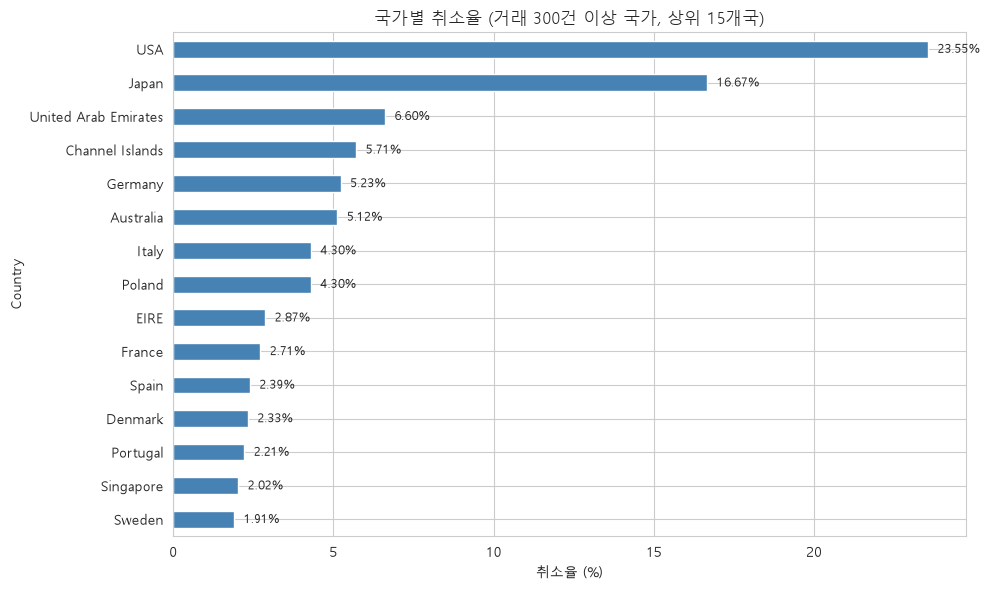

In [32]:
# 상위 15개국 시각화
plt.figure(figsize=(10, 6))
ax = country_cancel_filtered.head(15).plot(kind='barh', color='steelblue')
plt.xlabel('취소율 (%)')
plt.title('국가별 취소율 (거래 300건 이상 국가, 상위 15개국)')
plt.gca().invert_yaxis()  # 위에서부터 취소율 높은 순으로

# 각 막대 끝에 수치 라벨 추가
for i, value in enumerate(country_cancel_filtered.head(15)):
    ax.text(value + 0.3, i, f'{value:.2f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [21]:
# USA, Japan의 실제 거래 건수와 취소 건수 확인

for country in ['USA', 'Japan']:
    subset = df[df['Country'] == country]
    total = len(subset)
    cancelled = subset['is_cancelled'].sum()
    print(f'{country}: 전체 {total}건, 취소 {cancelled}건, 취소율 {cancelled/total*100:.2f}%')

USA: 전체 535건, 취소 126건, 취소율 23.55%
Japan: 전체 582건, 취소 97건, 취소율 16.67%


### 2-1 결과 해석

USA(535건 중 126건, 23.55%), Japan(582건 중 97건, 16.67%) 모두
충분한 표본 크기를 가지고 있어, 취소율 차이는 소수 사례에 의한
우연이 아닌 실제 구조적 패턴일 가능성이 높다.

-> 다만 원인(배송 거리, 환율, 특정 대량 구매자 등)까지는 바로 단정하기는 어렵다. 
-> 후속 분석
주제..!

## 2-2. 요일별 취소율 비교

### "요일에 따라 취소율에 차이가 있는가?" 
-> 주말 주문이
평일보다 충동구매성이 강해 취소가 더 많을 수 있다는 가설도 좋을듯!

In [27]:
# 요일 순서 - 월요일 ~ 일요일
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

weekday_cancel = df.groupby('weekday')['is_cancelled'].agg(
    전체건수='count',
    취소건수='sum'
)
weekday_cancel['취소율(%)'] = (weekday_cancel['취소건수'] / weekday_cancel['전체건수'] * 100).round(2)
weekday_cancel = weekday_cancel.reindex(weekday_order)

weekday_cancel

,전체건수,취소건수,취소율(%)
weekday,,,
Monday,189084,3102,1.64
Tuesday,196626,4201,2.14
Wednesday,185051,3407,1.84
Thursday,203149,4711,2.32
Friday,153803,2969,1.93
Saturday,402,0,0.00
Sunday,139256,1104,0.79


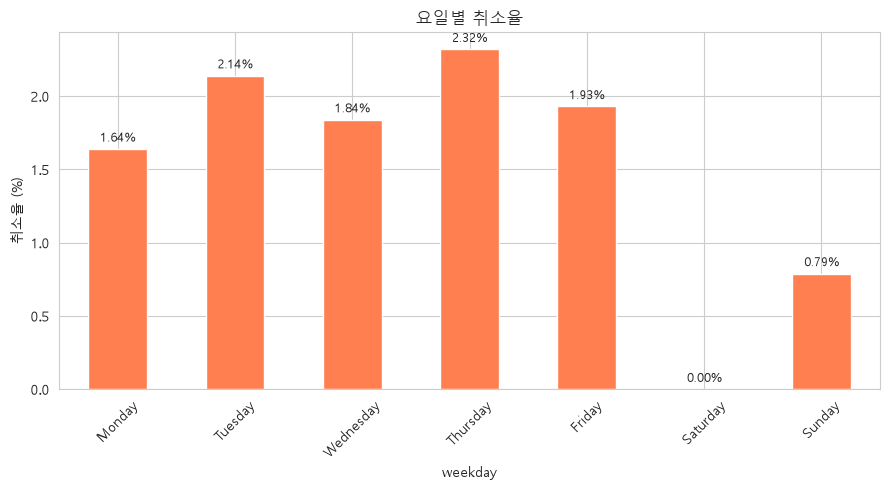

In [33]:
plt.figure(figsize=(9, 5))
ax = weekday_cancel['취소율(%)'].plot(kind='bar', color='coral')
plt.ylabel('취소율 (%)')
plt.title('요일별 취소율')
plt.xticks(rotation=45)

# 각 막대 위에 수치 라벨 추가
for i, value in enumerate(weekday_cancel['취소율(%)']):
    ax.text(i, value + 0.05, f'{value:.2f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [30]:
df['weekday'].value_counts()
weekday_cancel

,전체건수,취소건수,취소율(%)
weekday,,,
Monday,189084,3102,1.64
Tuesday,196626,4201,2.14
Wednesday,185051,3407,1.84
Thursday,203149,4711,2.32
Friday,153803,2969,1.93
Saturday,402,0,0.00
Sunday,139256,1104,0.79


### 2-2 결과 해석

- Thursday(2.32%), Tuesday(2.14%)가 취소율이 가장 높고,
  Sunday(0.79%)가 가장 낮다. 가설 "주말이 충동구매성이라
  취소가 더 많을 것"과는 반대로, 오히려 평일 취소율이 더 높게 나타났다.
  -> 이는 이 데이터가 일반 소비자(B2C)가 아닌 도매(B2B) 거래이기 때문에,
  주중 업무시간에 이루어지는 구매 결정 번복이 더 많을 가능성을 시사한다.
- Saturday는 전체 거래가 402건으로 다른 요일에 비해
현저히 적다. -> 이 업체가 토요일에는 거의 영업하지 않음을 보여준다.

-> 다만 402건 중 취소가 0건이라는 결과가 "토요일에는 구조적으로
취소가 발생하지 않는다"는 의미인지, 표본이 작아 우연히
취소가 한 건도 포함되지 않은 것인지는 현재는 판단할 수 없다.
-> 이 항목은 확정적 결론 없이 한계로 남겨둔다.

### 2-3. 시간대별 취소율 비교

하루 중 몇 시에 주문이 몰리고, 그중 어느 시간대에 취소가 더 많이 발생하는지 확인해본다.

e.g. 업무 시작 직후나 마감 직전같이 바쁜 시간대에 실수 주문이 늘어나 취소로 이어질 가능성?

In [34]:
#시간대별 취소율 계산 
hour_cancel = df.groupby('hour')['is_cancelled'].agg(
    전체건수='count',
    취소건수='sum'
)
hour_cancel['취소율(%)'] = (hour_cancel['취소건수'] / hour_cancel['전체건수'] * 100).round(2)

hour_cancel

,전체건수,취소건수,취소율(%)
hour,,,
6,41,40,97.56
7,1127,63,5.59
8,15985,296,1.85
9,68324,999,1.46
10,93248,2027,2.17
11,121780,2567,2.11
12,159846,2620,1.64
13,150308,2485,1.65
14,141513,2114,1.49


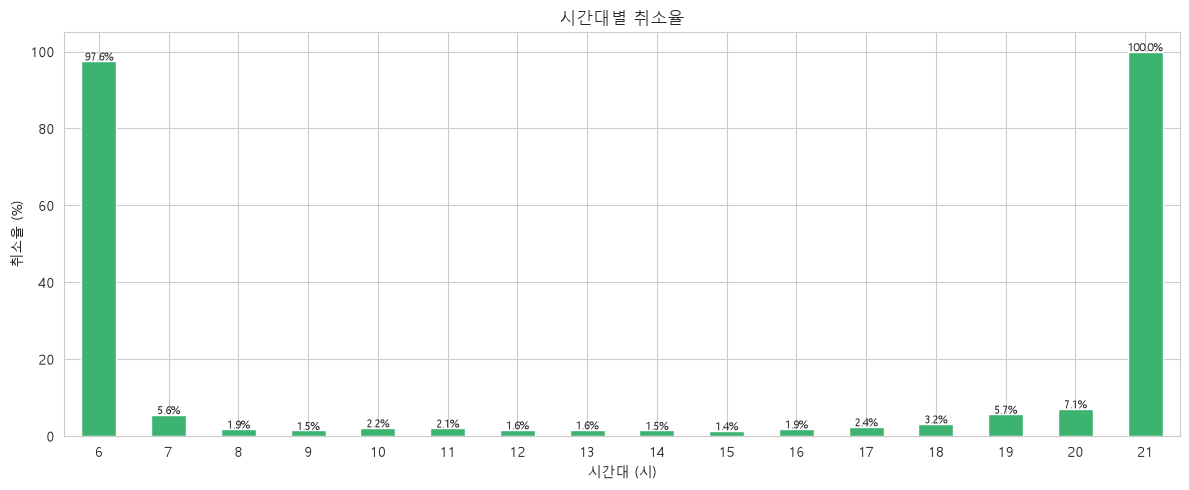

In [35]:
#시간대별 취소율 시각화
plt.figure(figsize=(12, 5))
ax = hour_cancel['취소율(%)'].plot(kind='bar', color='mediumseagreen')
plt.xlabel('시간대 (시)')
plt.ylabel('취소율 (%)')
plt.title('시간대별 취소율')
plt.xticks(rotation=0)

# 막대 위에 수치 라벨 추가
for i, value in enumerate(hour_cancel['취소율(%)']):
    ax.text(i, value + 0.1, f'{value:.1f}%', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

In [36]:
hour_cancel.loc[[6, 21]]

,전체건수,취소건수,취소율(%)
hour,,,
6,41,40,97.56
21,1,1,100.00


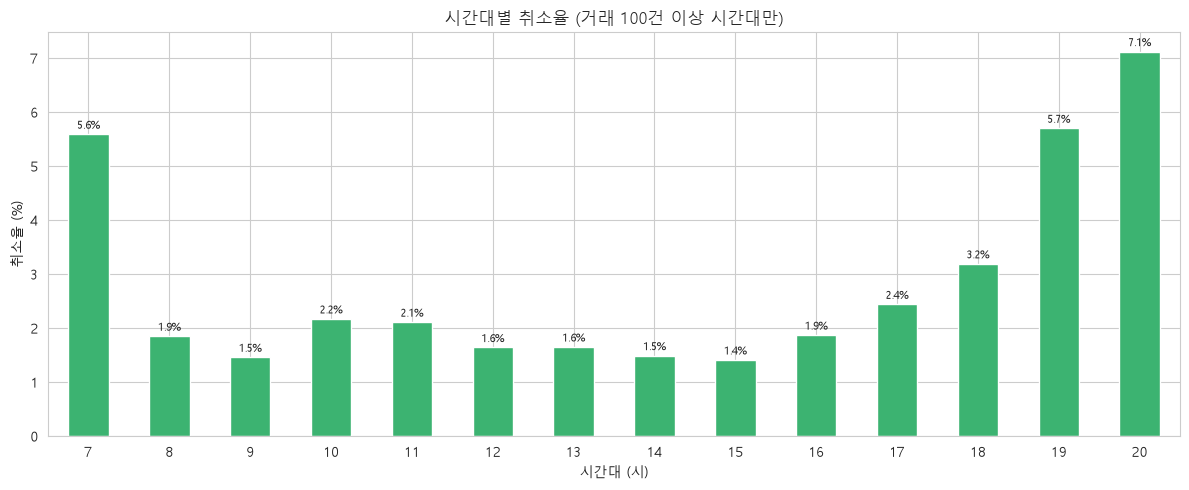

In [38]:
# 표본이 너무 적은 시간대(100건 미만)는 제외하고 다시 그리기
hour_cancel_filtered = hour_cancel[hour_cancel['전체건수'] >= 100]

plt.figure(figsize=(12, 5))
ax = hour_cancel_filtered['취소율(%)'].plot(kind='bar', color='mediumseagreen')
plt.xlabel('시간대 (시)')
plt.ylabel('취소율 (%)')
plt.title('시간대별 취소율 (거래 100건 이상 시간대만)')
plt.xticks(rotation=0)

for i, value in enumerate(hour_cancel_filtered['취소율(%)']):
    ax.text(i, value + 0.1, f'{value:.1f}%', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

### 2-3 결과 해석

6시(41건)와 21시(1건)는 다른 시간대에 비해 표본이 극히 적어, 해당 취소율은 통계적으로 신뢰할 수 없는 값으로 판단해 분석에서 제외. (100건 미만 시간대 필터링).


-> 7-20시 기준
- 취소율은 대체로 1.4%-7.1% 사이에 분포
- 19시와 20시 등 저녁 시간대에 취소율이 다소 높아지는 경향이 있다. 
- 반면 업무 초반? 업무 중반 시간대(13~15시)는 상대적으로 낮은 취소율을 보인다.

## Step 3. 주문 수량과 취소의 관계

### "주문 수량(대량구매 여부)이 취소 발생과 관련이 있는가?"
-> 대량 주문일수록 실수 주문이나 재고 확보 실패 등으로 취소될 가능성이 다를 수 있다는 가설을 검증한다.

단, Quantity는 취소 거래에서 음수로 기록되므로, 절댓값을 기준으로 비교한다.

In [41]:
# Quantity의 절댓값 (순수 거래값 확인)
df['quantity_abs'] = df['Quantity'].abs()

# 취소 여부에 따른 주문 규모(절댓값) 기초 통계 
df.groupby('is_cancelled')['quantity_abs'].describe()

,count,mean,std,min,25%,50%,75%,max
is_cancelled,,,,,,,,
False,1047877.0,11.686156,135.190507,1.0,1.0,3.0,11.0,80995.0
True,19494.0,25.186929,805.104905,1.0,1.0,2.0,6.0,80995.0


### 기초통계 해석

취소 거래의 평균 주문 수량(25.19개)은 정상 거래(11.69개)보다 높지만,
중앙값은 오히려 취소 거래(2개)가 정상 거래(3개)보다 낮다. 평균과
중앙값이 상반된 결론을 보이는 이유는, 취소 거래의 표준편차(805.10)가
정상거래(135.19)보다 훨씬 커서 소수의 초대형 주문(최댓값 80,995개,
양쪽 그룹 동일)이 평균을 왜곡시켰기 때문으로 판단된다.

-> 평균이나 중앙값만으로 "주문 수량과 취소의 관계"를 판단하는
것은 오해의 소지가 있다.

-> 주문 수량을 **구간으로 나누어** 구간별 취소율을
비교하는 방식으로 접근한다.


In [42]:
# 주문 규모를 구간으로 나누기
bins = [0, 5, 20, 50, 100, df['quantity_abs'].max()]
labels = ['1-5개', '6-20개', '21-50개', '51-100개', '101개 이상']
df['quantity_group'] = pd.cut(df['quantity_abs'], bins=bins, labels=labels)

qty_cancel = df.groupby('quantity_group', observed=True)['is_cancelled'].agg(
    전체건수='count',
    취소건수='sum'
)
qty_cancel['취소율(%)'] = (qty_cancel['취소건수'] / qty_cancel['전체건수'] * 100).round(2)

qty_cancel

,전체건수,취소건수,취소율(%)
quantity_group,,,
1-5개,637391,14221,2.23
6-20개,313438,3493,1.11
21-50개,89928,1105,1.23
51-100개,14908,259,1.74
101개 이상,11706,416,3.55


### 결과 해석

주문 수량과 취소율은 단순 비례 관계가 아니라, **비선형적인 패턴**을
보인다. 6-20개 구간에서 취소율이 1.11%로 가장 낮고, 이보다 작은
구간(1-5개, 2.23%)과 훨씬 큰 구간(101개 이상, 3.55%) 양쪽에서
다시 높아진다.

특히 101개 이상 초대량 주문의 취소율(3.55%)은 최저 구간(1.11%)의
**3배 이상**에 달한다. 전체 거래 중 초대량 주문의 비중은 1.1%
(11,706건/1,067,371건)에 불과하지만, 취소율이 유독 높다는 점에서
이 구간은 소수이지만 관리가 특히 필요한 리스크 구간으로 볼 수 있다.

다만 이 데이터에는 취소 사유나 고객 유형(개인/기업)을 구분해주는
정보가 없어, 대량 주문일수록 재고 확보나 계약 조건 관련 이슈로
취소될 가능성, 소량 주문일수록 개인 구매자의 변심 가능성 등은
가능한 가설일 뿐이며, 이를 검증하려면 취소 사유 데이터 등 추가
정보가 필요하다.

각 구간 모두 최소 11,706건 이상의 표본을 확보하고 있어, 이 패턴
자체는 표본 크기에 의한 왜곡이 아닌 것으로 판단된다.


## Step 4. 상품(카테고리)별 취소율 분석

### "특정 상품군에서 취소율이 유독 높게 나타나는가?"

*이 데이터에는 상품을 카테고리로 분류해주는 컬럼이 따로 없으므로,
StockCode(상품 코드) 단위로 취소율이 높은 상품을 직접 찾아본다.

In [48]:
# 상품(StockCode)별 전체건수, 취소건수, 취소율 계산
product_cancel = df.groupby('StockCode')['is_cancelled'].agg(
    전체건수='count',
    취소건수='sum'
)
product_cancel['취소율(%)'] = (product_cancel['취소건수'] / product_cancel['전체건수'] * 100).round(2)

# 표본이 너무 적은 상품(예: 30건 미만)은 제외 (착시 방지)
product_cancel_filtered = product_cancel[product_cancel['전체건수'] >= 30]

In [49]:
# 취소율 높은 순으로 상위 15개 상품 확인
product_cancel_filtered.sort_values('취소율(%)', ascending=False).head(15)

,전체건수,취소건수,취소율(%)
StockCode,,,
D,177,172,97.18
S,104,101,97.12
AMAZONFEE,43,39,90.70
BANK CHARGES,102,67,65.69
ADJUST,67,31,46.27
79323B,112,51,45.54
M,1421,538,37.86
79323GR,123,37,30.08
23064,34,10,29.41


In [50]:
# Description(상품명)까지 같이 확인
top15_codes = product_cancel_filtered.sort_values('취소율(%)', ascending=False).head(15).index.tolist()

for code in top15_codes:
    desc = df[df['StockCode'] == code]['Description'].mode()
    desc_text = desc[0] if len(desc) > 0 else '(설명 없음)'
    print(f'{code}: {desc_text}')

D: Discount
S: SAMPLES
AMAZONFEE: AMAZON FEE
BANK CHARGES: Bank Charges
ADJUST: Adjustment by john on 26/01/2010 16
79323B: BLACK CHERRY LIGHTS
M: Manual
79323GR: GREEN CHERRY LIGHTS
23064: CINDERELLA CHANDELIER 
79323G: GOLD  CHERRY LIGHTS
79323S:  SILVER CHERRY LIGHTS
79323W:  WHITE CHERRY LIGHTS
79323LP: LIGHT PINK CHERRY LIGHTS
79323P: PINK CHERRY LIGHTS
79341: WILLOW BRANCH LIGHTS.


### 4-1 발견: 회계/시스템 코드와 실제 상품 구분

취소율 상위 목록에 `D`(할인), `S`(샘플), `AMAZONFEE`(아마존 수수료),
`BANK CHARGES`(은행 수수료), `ADJUST`(담당자 수기 조정), `M`(수동 입력) 등이 포함됨

→ 이는 실제 판매 상품이 아니라 **회계·시스템 처리 과정에서 생기는 코드**로 확인됨

→ 이후 분석에서는 이러한 회계/시스템 코드를 제외하고, **실제 상품 코드만**을 대상으로 취소율을 재계산함

In [57]:
# 회계/시스템 코드 목록 (알파벳 한 글자짜리 특수 코드 + 확인된 항목)
non_product_codes = ['D', 'S', 'M', 'AMAZONFEE', 'BANK CHARGES', 'ADJUST',
                       'POST', 'DOT', 'C2', 'CRUK']  # 자주 등장하는 특수코드 미리 포함

# StockCode가 특수 코드 목록에 없는 것만 남기기
df_products_only = df[~df['StockCode'].isin(non_product_codes)]

# 상품별 취소율 계산 (진짜 상품만)
product_cancel2 = df_products_only.groupby('StockCode')['is_cancelled'].agg(
    전체건수='count',
    취소건수='sum'
)
product_cancel2['취소율(%)'] = (product_cancel2['취소건수'] / product_cancel2['전체건수'] * 100).round(2)

product_cancel2_filtered = product_cancel2[product_cancel2['전체건수'] >= 30]
product_cancel2_filtered.sort_values('취소율(%)', ascending=False).head(15)

,전체건수,취소건수,취소율(%)
StockCode,,,
79323B,112,51,45.54
79323GR,123,37,30.08
23064,34,10,29.41
79323G,90,26,28.89
79323S,81,23,28.40
79323W,478,126,26.36
79323LP,232,60,25.86
79323P,354,86,24.29
79341,106,24,22.64


In [54]:
# 79323로 시작하는 코드를 하나의 상품군으로 묶어서 확인
cherry_lights = df_products_only[df_products_only['StockCode'].str.startswith('79323')]

total = len(cherry_lights)
cancelled = cherry_lights['is_cancelled'].sum()
print(f'체리 라이트 시리즈 전체: {total}건, 취소: {cancelled}건, 취소율: {cancelled/total*100:.2f}%')

체리 라이트 시리즈 전체: 1470건, 취소: 409건, 취소율: 27.82%


### 결과: 체리 라이트 시리즈의 이상 취소율

StockCode가 79323으로 시작하는 체리 라이트 시리즈(7개 색상 변형)를
하나의 상품군으로 묶어 확인한 결과, 전체 1,470건 중 409건이 취소되어
취소율이 27.82%로 나타났다. 이는 전체 평균 취소율(1.83%)의 약 15배에
달하는 수치다.

7개 색상 변형 모두가 상위 취소율 목록에 동시에 포함되었다는 점에서,
이는 특정 색상의 인기 문제가 아니라 해당 상품 라인 자체의 구조적
문제일 가능성을 시사한다. (제품 하자, 계절성 상품 특유의 반품 패턴? 등)

다만, 반품 사유 정보가 없어 정확한 원인은
확정할 수 없으며, 표본 크기(1,470건)를 고려할 때 이 패턴이 우연에
의한 것일 가능성은 낮다고 판단된다.

## Step 5. 요인별 유의성 검증

지금까지 그래프로 확인한 차이(국가별, 요일별 취소율 차이 등)가
통계적으로 유의미한지 검정한다.


### 5-1. 카이제곱 검정: 국가와 취소 여부의 관계

카이제곱 검정은 "두 범주형 변수(국가, 취소여부)가 서로 관련이
있는가"를 확인하는 통계 검정이다. 귀무가설(H0)은 "국가와 취소
여부는 서로 관련이 없다(독립이다)"이며, p-value가 0.05보다
작으면 이 귀무가설을 기각하고 "관련이 있다"고 결론 내린다.

In [59]:
from scipy.stats import chi2_contingency

# 표본이 충분한(300건 이상) 국가만 대상으로 검정
valid_countries = country_cancel_filtered.index.tolist()
df_country_valid = df[df['Country'].isin(valid_countries)]

# 국가 x 취소여부 교차표(contingency table) 생성
contingency_table = pd.crosstab(df_country_valid['Country'], df_country_valid['is_cancelled'])

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f'카이제곱 통계량: {chi2:.2f}')
print(f'p-value: {p_value:.10f}')
print(f'자유도: {dof}')

카이제곱 통계량: 3965.17
p-value: 0.0000000000
자유도: 26


### 5-1 결과: 카이제곱 검정 (국가 × 취소 여부)

카이제곱 통계량 3965.17, p-value < 0.0001로 나타나, 국가와 취소
여부는 통계적으로 유의미한 관련이 있는 것으로 확인되었다. 즉
국가별 취소율 차이는 우연에 의한 것이 아니라 통계적으로 뒷받침되는
패턴이다.

### 5-2. 카이제곱 검정: 요일과 취소 여부의 관계

In [60]:

### 요일 x 취소여부 교차표 생성
contingency_weekday = pd.crosstab(df['weekday'], df['is_cancelled'])

chi2_wd, p_value_wd, dof_wd, expected_wd = chi2_contingency(contingency_weekday)

print(f'카이제곱 통계량: {chi2_wd:.2f}')
print(f'p-value: {p_value_wd:.10f}')
print(f'자유도: {dof_wd}')

카이제곱 통계량: 1263.57
p-value: 0.0000000000
자유도: 6


### 5-2 결과: 카이제곱 검정 (요일 × 취소 여부)

카이제곱 통계량 1263.57, p-value < 0.0001로 나타나, 요일과 취소
여부 역시 통계적으로 유의미한 관련이 있는 것으로 확인되었다.
다만 Saturday(402건)는 다른 요일에 비해 표본이 현저히 적어,
이 검정 결과에서 요일별 세부 기여도를 해석할 때는 주의가
필요하다.

### 5-3. t검정: 주문 수량과 취소 여부의 관계

취소 거래와 정상 거래의 평균 주문 수량(quantity_abs)이 통계적으로
유의미하게 다른지 검정한다. 귀무가설(H0)은 "두 그룹의 평균 주문
수량은 같다"이며, p-value가 0.05보다 작으면 이를 기각하고
"차이가 있다"고 결론 내린다.

In [61]:
from scipy.stats import ttest_ind

cancelled_qty = df[df['is_cancelled'] == True]['quantity_abs']
normal_qty = df[df['is_cancelled'] == False]['quantity_abs']

t_stat, p_value_t = ttest_ind(cancelled_qty, normal_qty, equal_var=False)

print(f't 통계량: {t_stat:.2f}')
print(f'p-value: {p_value_t:.10f}')

t 통계량: 2.34
p-value: 0.0192584682


### 5-3 결과: t검정 (주문 수량 × 취소 여부)

t 통계량 2.34, p-value 0.0193으로, 통계적 기준(p<0.05)상으로는
취소 거래와 정상 거래의 평균 주문 수량에 유의미한 차이가 있다는
결과가 나왔다. 

다만 이 t검정은 앞서 확인한 것처럼 양쪽 그룹 모두에
극단적으로 큰 주문(최댓값 80,995개)이 포함되어 있어 평균 자체가
왜곡되어 있으므로, 이 결과를 그대로 신뢰하기는
어렵다.

국가·요일 검정(카이제곱 통계량 각각 3965.17, 1263.57)에 비해 t
통계량(2.34)이 현저히 약한 것도 이 검정의 설명력이 상대적으로
낮다는 것을 보여준다. 

-> 주문 수량과 취소의 관계는 평균
비교보다 앞서 확인한 **구간별 취소율 비교**(6-20개 구간에서 최저,
양극단에서 증가하는 비선형 패턴)가 더 신뢰할 수 있는 근거로
판단된다.